In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from pathlib import Path; file_path = Path.cwd().parents[1] / "code" / "results" / "exp_1.csv"
data = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")

In [2]:
data

,n,p,b,c,b/c,pC,pD,pC > pD
0,6,0.2,5,1,5.0,0.1658,0.1643,1
1,6,0.2,6,1,6.0,0.1661,0.1591,1
2,6,0.2,7,1,7.0,0.1699,0.1700,0
3,6,0.2,8,1,8.0,0.1621,0.1666,0
4,6,0.2,9,1,9.0,0.1726,0.1623,1
...,...,...,...,...,...,...,...,...
475,20,0.8,15,3,5.0,0.0315,0.0416,0
476,20,0.8,18,3,6.0,0.0384,0.0379,1
477,20,0.8,21,3,7.0,0.0370,0.0375,0
478,20,0.8,24,3,8.0,0.0380,0.0377,1


Does pC > pD when b/c > 7?

<Axes: xlabel='pC > pD', ylabel='b/c'>

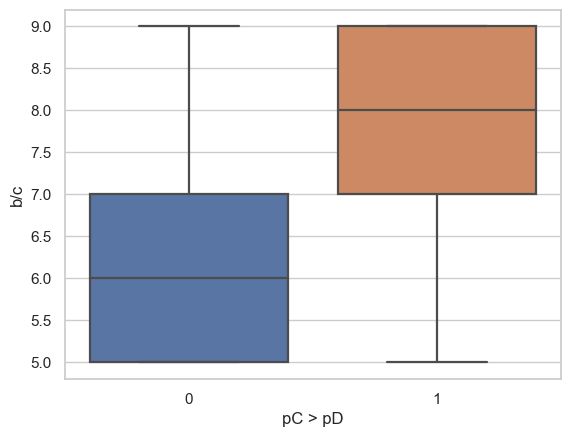

In [3]:
# Boxplot of pC > pD outcomes per b/c values
sns.boxplot(data=data, x="pC > pD", y="b/c", width=0.8, hue="pC > pD", legend=False, linewidth=1.6)

Is 7 still the critical value for pC > pD when N ≥ 17?

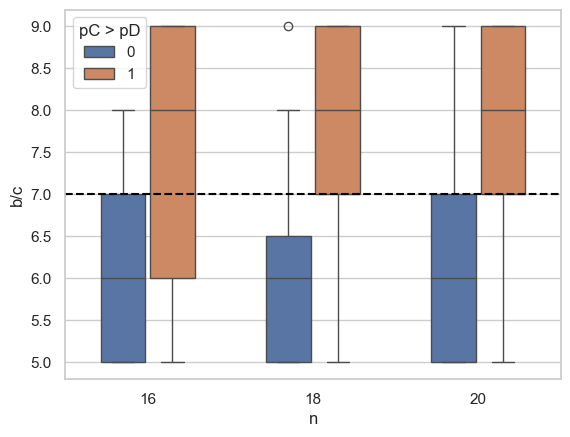

In [4]:
# Boxplot of b/c values per pC > pD outcomes for all n > 15
ax = sns.boxplot(data=data[data["n"] > 15], x="n", y="b/c", width=0.6, gap = 0.1, hue="pC > pD", legend=True)
ax.axhline(7, color="black", linestyle="--")

Does pC > pD occur regardless of n?

<Axes: xlabel='n', ylabel='count'>

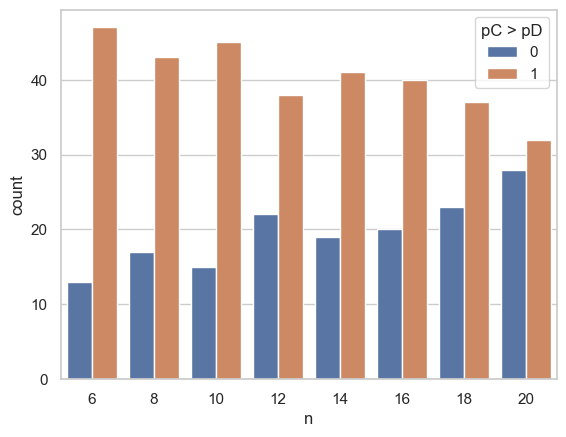

In [5]:
# Histogram of pC > pD outcomes per n
sns.countplot(data=data, x="n", hue="pC > pD")

Do pC outcomes increase relatively to pD outcomes with increasing p?

<Axes: xlabel='p', ylabel='pC > pD'>

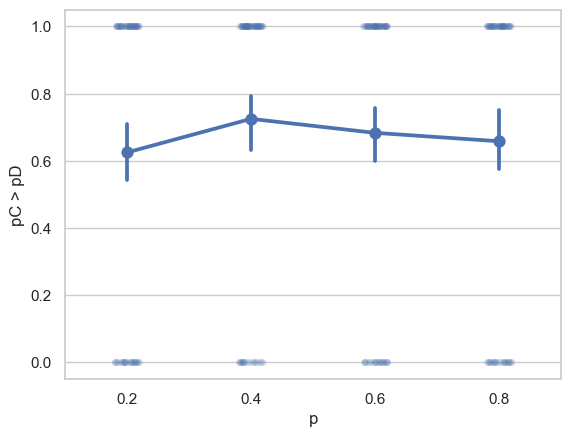

In [91]:
# Frequencies of pC > pD = 1
sns.stripplot(data=data, x="p", y="pC > pD", alpha=0.1, size=5)
sns.pointplot(data=data, x="p", y="pC > pD", errorbar="ci")

<Axes: xlabel='pC', ylabel='Density'>

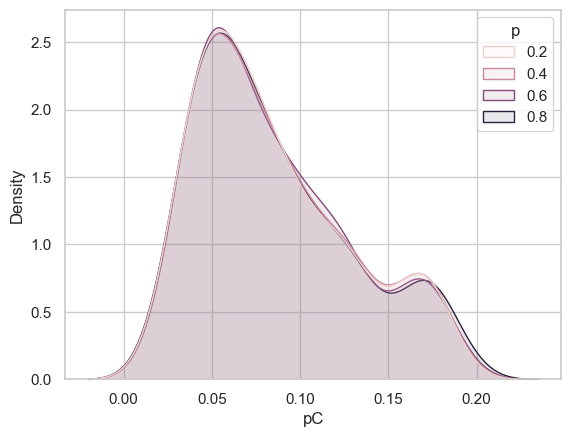

In [87]:
# Density of pC values of different p values
sns.kdeplot(data=data, x="pC", hue="p", fill=True, alpha=0.1)

Other visualizations

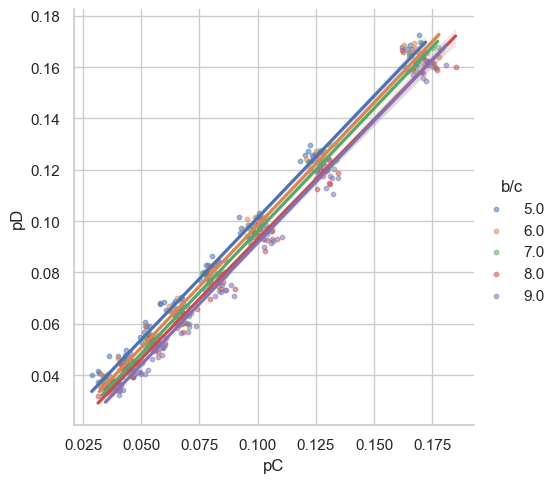

In [7]:
# Regression line of b/c values 
sns.lmplot(data=data, x="pC", y="pD", hue="b/c", scatter_kws={"s": 10, "alpha": 0.5})

[(0.02, 0.19), (0.02, 0.19)]

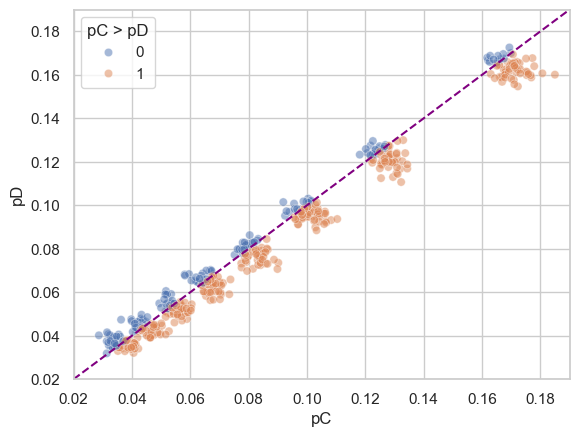

In [10]:
# pC per pD values
ax = sns.scatterplot(data=data, x="pC", y="pD", hue="pC > pD", alpha=0.5)
ax.axline((0, 0), slope=1, color="purple", linestyle="--")
ax.set(xlim=(0.02, 0.19), ylim=(0.02, 0.19))

<Axes: xlabel='n', ylabel='pC'>

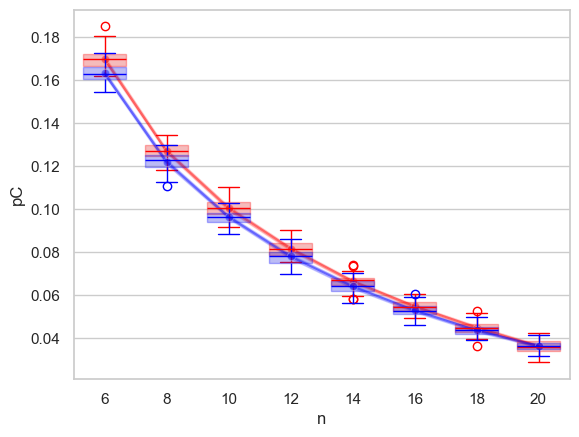

In [73]:
# pC values per n (red)
ax = sns.lineplot(data=data, x=data["n"].astype(str), y="pC", alpha=0.5, color="red", marker="o", estimator="mean")
sns.boxplot(data=data, x="n", y="pC", color="red", width=0.7, ax=ax, boxprops=dict(alpha=0.3), linecolor="red")

# pD values per n (blue)
sns.lineplot(data=data, x=data["n"].astype(str), y="pD", alpha=0.5, color="blue", marker="o", estimator="mean", ax=ax)
sns.boxplot(data=data, x="n", y="pD", color="blue", width=0.7, ax=ax, boxprops=dict(alpha=0.3), linecolor="blue")

<Axes: xlabel='b', ylabel='pC'>

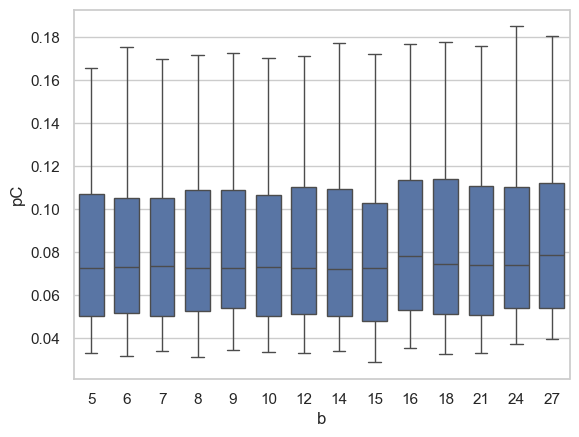

In [100]:
# pC outcomes per benefit values to see whether magnitude affects outcomes
sns.boxplot(data=data, x="b", y="pC", width=0.7)

<Axes: xlabel='b', ylabel='pC'>

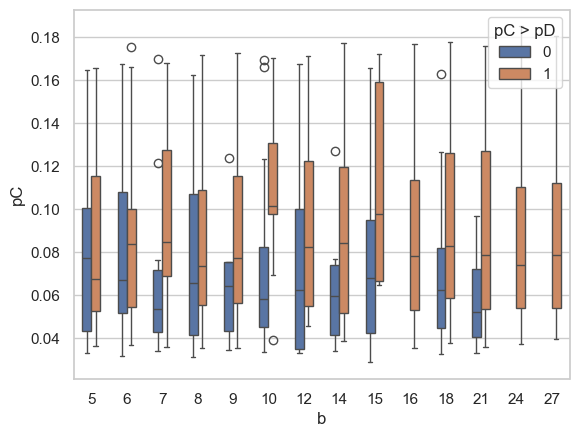

In [101]:
sns.boxplot(data=data, x="b", y="pC", hue="pC > pD", width=0.5)